In [1]:
import matplotlib.pyplot as plt
import pickle

from pmbrl.model2 import Model
from pmbrl.data import Experiment_Data, get_data_expanded

In [2]:
nome_do_arquivo = 'triplet.pkl'

with open(nome_do_arquivo, 'rb') as arquivo:
    exp = pickle.load(arquivo)
    data = exp['data']
    model = exp['model']

del exp
del arquivo

In [3]:
expansions = {
    'estimated_p': ['p0', 'p1'],
    's_': ['s0', 's1', 's2', 's3'],
    's__': ['s_0', 's_1', 's_2', 's_3'],
}


df = data.evaluation_data[data.evaluation_data['episode'] == 98].copy().reset_index(drop=True)
df = get_data_expanded(df, expansions)
df.head()

,step,episode,p,s,a,r,s_,a_,r_,s__,...,p0,p1,s0,s1,s2,s3,s_0,s_1,s_2,s_3
0,0,98,"(0.1955406148449595, 0.6245501454716056)","(0.044, 0.035, -0.043, -0.021)",1,1.0,"(0.045, 0.229, -0.043, -0.284)",0.0,1.0,"(0.05, 0.036, -0.049, -0.044)",...,0.260,0.790,0.045,0.229,-0.043,-0.284,0.050,0.036,-0.049,-0.044
1,1,98,"(0.1955406148449595, 0.6245501454716056)","(0.045, 0.229, -0.043, -0.284)",0,1.0,"(0.05, 0.036, -0.049, -0.044)",0.0,1.0,"(0.05, -0.156, -0.05, 0.194)",...,0.303,0.665,0.050,0.036,-0.049,-0.044,0.050,-0.156,-0.050,0.194
2,2,98,"(0.1955406148449595, 0.6245501454716056)","(0.05, 0.036, -0.049, -0.044)",0,1.0,"(0.05, -0.156, -0.05, 0.194)",0.0,1.0,"(0.047, -0.349, -0.046, 0.432)",...,0.296,0.686,0.050,-0.156,-0.050,0.194,0.047,-0.349,-0.046,0.432
3,3,98,"(0.1955406148449595, 0.6245501454716056)","(0.05, -0.156, -0.05, 0.194)",0,1.0,"(0.047, -0.349, -0.046, 0.432)",1.0,1.0,"(0.04, -0.155, -0.037, 0.168)",...,0.227,0.654,0.047,-0.349,-0.046,0.432,0.040,-0.155,-0.037,0.168
4,4,98,"(0.1955406148449595, 0.6245501454716056)","(0.047, -0.349, -0.046, 0.432)",1,1.0,"(0.04, -0.155, -0.037, 0.168)",0.0,1.0,"(0.037, -0.348, -0.034, 0.41)",...,0.198,0.649,0.040,-0.155,-0.037,0.168,0.037,-0.348,-0.034,0.410


# Treino 

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim

target_value = torch.tensor(df[['s_0', 's_1', 's_2', 's_3']].values)
param = torch.tensor(df[['p0', 'p1']].mean().values, requires_grad=True)
print(f'initial value for input Param: {[round(p,4) for p in param.tolist()]}') 
input_values = torch.tensor(df[['s0', 's1', 's2', 's3', 'a_']].values) 
input_size = 4+1+2
hidden_size = 10
output_size = 2
learning_rate = 0.1
num_epochs = 1000

m = model.transition_estimator.state_layer
optimizer = optim.Adam([param], lr=learning_rate)
criterion = nn.MSELoss(reduction='none')

# 4. Optimization Loop
history = []

for p in m.parameters():
    p.requires_grad = False


for epoch in range(num_epochs):
    # Forward pass
    state_inputs = torch.concat([input_values, param.repeat((input_values.shape[0], 1))], dim=1)
    output = m(state_inputs.float())  # Add batch dimension

    # Calculate the loss
    # loss = criterion(output.float(), target_value.float())
    
    def normilize(v): 
        mins = input_values[:,:-1].min(axis=0).values.repeat((v.shape[0], 1))
        maxs = input_values[:,:-1].max(axis=0).values.repeat((v.shape[0], 1))
        rang = maxs - mins
        return (v - mins) / rang
    loss = criterion(normilize(output).float(), normilize(target_value).float())
    # loss = torch.sqrt(loss.sum(axis=1).mean())
    # loss = torch.sqrt(loss.mean(axis=1).sum())
    loss = loss.mean()
    # loss = loss.sum()

    # Backward and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    history.append((epoch, param.tolist(), loss.item()))

    if (epoch + 1) % 100 == 0:
        # print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}, Input Param: {param.item():.4f}, Output: {output.item():.4f}')
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}, Input Param: {[round(p,4) for p in param.tolist()]}')


initial value for input Param: [0.2833, 0.7573]
Epoch [100/1000], Loss: 0.0003, Input Param: [0.0556, 1.5128]
Epoch [200/1000], Loss: 0.0003, Input Param: [0.0547, 1.5161]
Epoch [300/1000], Loss: 0.0003, Input Param: [0.0547, 1.5161]
Epoch [400/1000], Loss: 0.0003, Input Param: [0.0547, 1.5161]
Epoch [500/1000], Loss: 0.0003, Input Param: [0.0547, 1.5161]
Epoch [600/1000], Loss: 0.0003, Input Param: [0.0547, 1.5161]
Epoch [700/1000], Loss: 0.0003, Input Param: [0.0547, 1.5161]
Epoch [800/1000], Loss: 0.0003, Input Param: [0.0547, 1.5161]
Epoch [900/1000], Loss: 0.0003, Input Param: [0.0547, 1.5161]
Epoch [1000/1000], Loss: 0.0003, Input Param: [0.0547, 1.5161]


In [5]:
results = data.get_evaluation_metrics()
df_result = results[results['episode'] == 98].copy()

In [6]:
df_result['rmse'] = df_result['rse_s0'] + df_result['rse_s1'] + df_result['rse_s2'] + df_result['rse_s3']
df_result.rmse.mean()

np.float64(0.10391566265060243)

# Original Predictions:

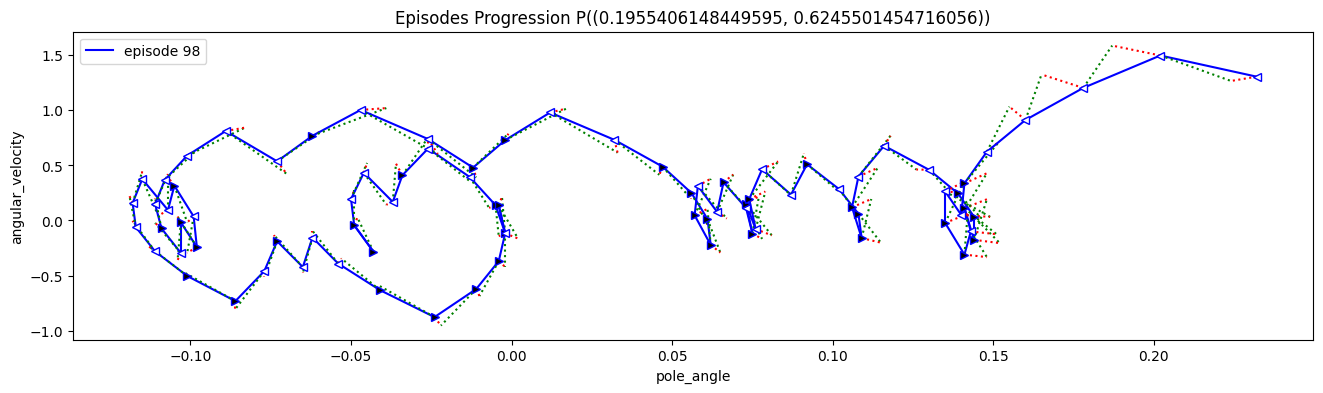

In [7]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 1, figsize=(16, 4))
data.plot_episode_progression_with_predictions(axs, 98)
plt.show()

# Optimized Param:

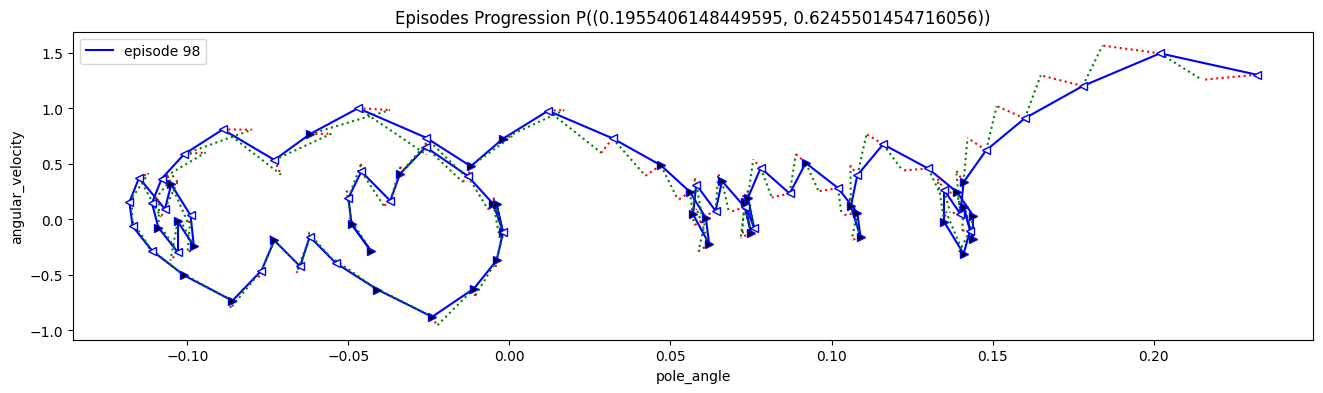

In [8]:
df = get_data_expanded(data.evaluation_data[data.evaluation_data.episode==98], {
    's_':['s0','s1','s2','s3'], 's__':['s_0','s_1','s_2','s_3'], 'p':['p_0','p_1'],
    # 'estimated_s':['estimated_s0','estimated_s1','estimated_s2','estimated_s3'], #'estimated_p':['estimated_p_0','estimated_p_1']
})
df[['estimated_s0','estimated_s1','estimated_s2','estimated_s3']] = output.detach().numpy() 


fig, axs = plt.subplots(1, 1, figsize=(16, 4))
data.plot_episode_progression_with_predictions(axs, 98, df=df)
plt.show()

In [9]:
del model
del data

In [10]:
import pandas as pd
import numpy as np

df = results.loc[results['episode']==98][['s0', 's1', 's2', 's3']].reset_index(drop=True).copy()

def rse(v1:pd.Series, v2:pd.Series) -> pd.Series:
    return np.sqrt(np.pow(v1-v2, 2))

# RMSE for state
for i, v in enumerate(['s0', 's1', 's2', 's3']):
    df[f'rse_{v}'] = rse(df[v], output.detach().numpy()[:,i])


df['rmse'] = df['rse_s0'] + df['rse_s1'] + df['rse_s2'] + df['rse_s3']
df.rmse.mean()


np.float64(0.08545974663007688)